# 02 — GPX Analysis & Visualization
Parse, analyse, and visually explore the route before generating any pacing plan.

In [1]:
import gpxpy
import numpy as np
import matplotlib.pyplot as plt
import folium
from pathlib import Path

GPX_FILE = Path("../data/TSB2026-LA_BOUCLE_CUGEOISE.gpx")

## 2.1 Parse GPX into a DataFrame

In [2]:
from trail_pacer.utils import gpx_to_dataframe

df = gpx_to_dataframe(GPX_FILE)
print(f"Track points : {len(df)}")
print(f"Total distance : {df['distance_m'].max() / 1000:.2f} km")
print(f"Min elevation : {df['elevation_m'].min():.0f} m")
print(f"Max elevation : {df['elevation_m'].max():.0f} m")
df.head()

Track points : 1218
Total distance : 26.27 km
Min elevation : 185 m
Max elevation : 1035 m


,lat,lon,elevation_m,distance_m
0,43.279237,5.703046,223.24,0.000000
1,43.279237,5.703046,222.66,0.580040
2,43.278894,5.703307,222.26,44.268764
3,43.278930,5.703258,221.61,50.011682
4,43.278837,5.703127,220.66,64.835659


## 2.2 Compute Derived Metrics

In [3]:
df["distance_km"]   = df["distance_m"] / 1000
df["elev_diff_m"]   = df["elevation_m"].diff().fillna(0)
df["gain_m"]        = df["elev_diff_m"].clip(lower=0)
df["loss_m"]        = df["elev_diff_m"].clip(upper=0).abs()
df["segment_m"]     = df["distance_m"].diff().fillna(1)
df["grade_pct"]     = (df["elev_diff_m"] / df["segment_m"].replace(0, np.nan) * 100).fillna(0)
df["grade_pct"]     = df["grade_pct"].clip(-50, 50)   # clip outlier artifacts

total_gain = df["gain_m"].sum()
total_loss = df["loss_m"].sum()
print(f"Total D+ : {total_gain:.0f} m  |  Total D- : {total_loss:.0f} m")

Total D+ : 1616 m  |  Total D- : 1616 m


## 2.3 Elevation Profile

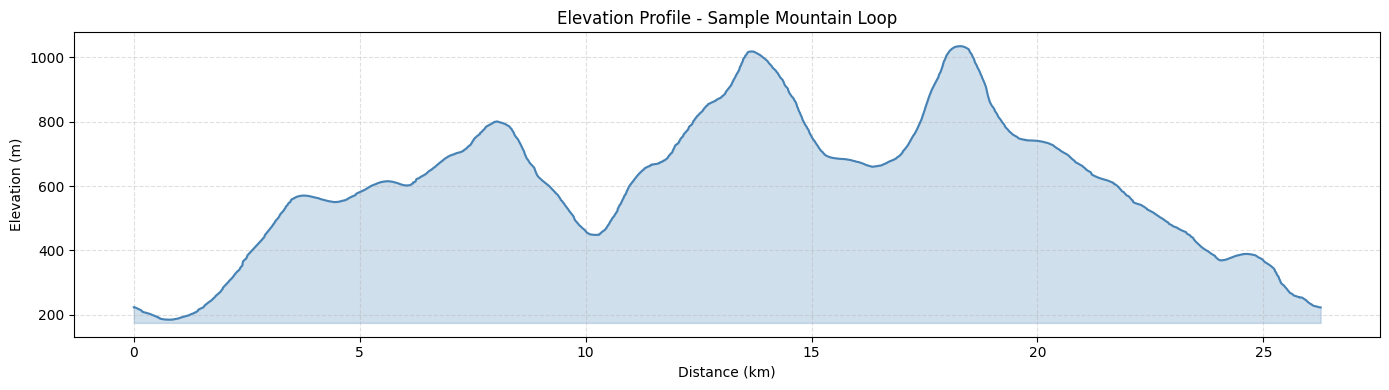

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(df["distance_km"], df["elevation_m"],
                df["elevation_m"].min() - 10,
                alpha=0.25, color="steelblue")
ax.plot(df["distance_km"], df["elevation_m"], color="steelblue", linewidth=1.5)
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Elevation (m)")
ax.set_title("Elevation Profile - Sample Mountain Loop")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
# plt.savefig("data/elevation_profile.png", dpi=150)
plt.show()

## 2.4 Grade Heatmap Along the Route

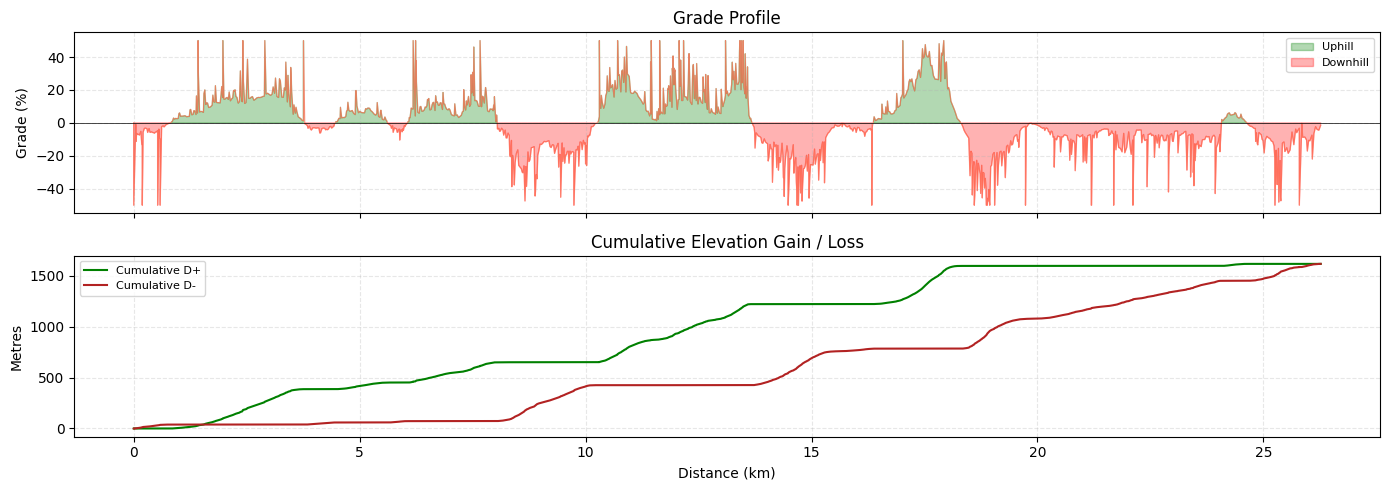

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

# Grade line
axes[0].plot(df["distance_km"], df["grade_pct"], color="tomato", linewidth=0.8, alpha=0.7)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].fill_between(df["distance_km"], df["grade_pct"], 0,
                     where=(df["grade_pct"] > 0), color="green", alpha=0.3, label="Uphill")
axes[0].fill_between(df["distance_km"], df["grade_pct"], 0,
                     where=(df["grade_pct"] < 0), color="red",   alpha=0.3, label="Downhill")
axes[0].set_ylabel("Grade (%)")
axes[0].set_title("Grade Profile")
axes[0].legend(fontsize=8)
axes[0].grid(True, linestyle="--", alpha=0.3)

# Cumulative D+
axes[1].plot(df["distance_km"], df["gain_m"].cumsum(), color="green",  label="Cumulative D+")
axes[1].plot(df["distance_km"], df["loss_m"].cumsum(), color="firebrick", label="Cumulative D-")
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("Metres")
axes[1].set_title("Cumulative Elevation Gain / Loss")
axes[1].legend(fontsize=8)
axes[1].grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
# plt.savefig("data/grade_heatmap.png", dpi=150)
plt.show()

## 2.5 Grade Distribution Histogram

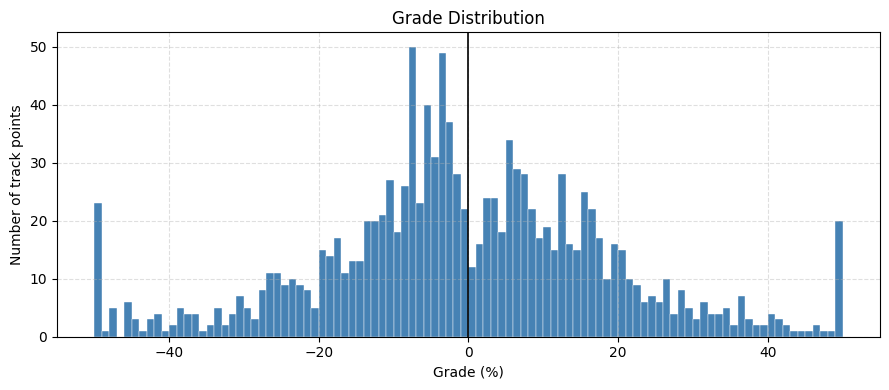

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df["grade_pct"], bins=100, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="black", linewidth=1.2)
ax.set_xlabel("Grade (%)")
ax.set_ylabel("Number of track points")
ax.set_title("Grade Distribution")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 2.6 Interactive Folium Map with Elevation Colour-Coding

In [7]:
def grade_to_colour(grade: float) -> str:
    """Map grade to a hex colour: green=flat, red=steep up, blue=steep down."""
    g = max(-30, min(30, grade))
    if g >= 0:
        r = int(min(255, g / 30 * 255))
        return f"#{r:02x}{255 - r:02x}00"
    else:
        b = int(min(255, abs(g) / 30 * 255))
        return f"#00{255 - b:02x}{b:02x}"

center_lat = df["lat"].mean()
center_lon = df["lon"].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=13, tiles="OpenTopoMap")

# Draw coloured polyline segments
coords    = list(zip(df["lat"], df["lon"]))
grades    = df["grade_pct"].tolist()
for i in range(len(coords) - 1):
    folium.PolyLine(
        locations=[coords[i], coords[i + 1]],
        color=grade_to_colour(grades[i]),
        weight=3, opacity=0.85
    ).add_to(m)

# Add waypoints
with open(GPX_FILE) as f:
    gpx_parsed = gpxpy.parse(f)

for wpt in gpx_parsed.waypoints:
    folium.Marker(
        location=[wpt.latitude, wpt.longitude],
        popup=wpt.name,
        icon=folium.Icon(color="red", icon="flag")
    ).add_to(m)

map_path = Path("data/interactive_map.html")
# m.save(str(map_path))
# print(f"✅ Interactive map saved to '{map_path}'")
m   # renders inline in Jupyter

## 2.7 Statistics Summary

In [8]:
stats = {
    "Total distance (km)":   round(df["distance_km"].max(), 2),
    "Total D+ (m)":          round(total_gain, 0),
    "Total D- (m)":          round(total_loss, 0),
    "Max elevation (m)":     round(df["elevation_m"].max(), 0),
    "Min elevation (m)":     round(df["elevation_m"].min(), 0),
    "Max grade (%)":         round(df["grade_pct"].max(), 1),
    "Min grade (%)":         round(df["grade_pct"].min(), 1),
    "Mean grade uphill (%)": round(df.loc[df["grade_pct"] > 0, "grade_pct"].mean(), 1),
}
for k, v in stats.items():
    print(f"  {k:<30} {v}")

  Total distance (km)            26.27
  Total D+ (m)                   1616.0
  Total D- (m)                   1616.0
  Max elevation (m)              1035.0
  Min elevation (m)              185.0
  Max grade (%)                  50.0
  Min grade (%)                  -50.0
  Mean grade uphill (%)          15.8
